In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import timm
import pickle

DATA_PATH = "D:/ML/RSNA2024"
CACHE_AUGMENTATIONS=False

c:\Users\manue\anaconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
timm.list_models("*resnet*", pretrained=True)

['cspresnet50.ra_in1k',
 'eca_resnet33ts.ra2_in1k',
 'ecaresnet26t.ra2_in1k',
 'ecaresnet50d.miil_in1k',
 'ecaresnet50d_pruned.miil_in1k',
 'ecaresnet50t.a1_in1k',
 'ecaresnet50t.a2_in1k',
 'ecaresnet50t.a3_in1k',
 'ecaresnet50t.ra2_in1k',
 'ecaresnet101d.miil_in1k',
 'ecaresnet101d_pruned.miil_in1k',
 'ecaresnet269d.ra2_in1k',
 'ecaresnetlight.miil_in1k',
 'gcresnet33ts.ra2_in1k',
 'gcresnet50t.ra2_in1k',
 'inception_resnet_v2.tf_ens_adv_in1k',
 'inception_resnet_v2.tf_in1k',
 'lambda_resnet26rpt_256.c1_in1k',
 'lambda_resnet26t.c1_in1k',
 'lambda_resnet50ts.a1h_in1k',
 'legacy_seresnet18.in1k',
 'legacy_seresnet34.in1k',
 'legacy_seresnet50.in1k',
 'legacy_seresnet101.in1k',
 'legacy_seresnet152.in1k',
 'nf_resnet50.ra2_in1k',
 'resnet10t.c3_in1k',
 'resnet14t.c3_in1k',
 'resnet18.a1_in1k',
 'resnet18.a2_in1k',
 'resnet18.a3_in1k',
 'resnet18.fb_ssl_yfcc100m_ft_in1k',
 'resnet18.fb_swsl_ig1b_ft_in1k',
 'resnet18.gluon_in1k',
 'resnet18.tv_in1k',
 'resnet18d.ra2_in1k',
 'resnet26.bt_i

In [3]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Data Processing

In [4]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df = df.fillna("Normal/Mild")
df.set_index("study_id", inplace=True)
df.head(10)

,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,left_neural_foraminal_narrowing_l5_s1,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
study_id,,,,,,,,,,,,,,,,,,,,,
4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild
11340341,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild
11943292,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
13317052,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Severe,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate
22191399,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Moderate


In [5]:
pd.unique(df["spinal_canal_stenosis_l1_l2"])

array(['Normal/Mild', 'Moderate', 'Severe'], dtype=object)

In [6]:
dfDescr = pd.read_csv(os.path.join(DATA_PATH, "train_series_descriptions.csv"))
uniqueSeriesDescr = np.array(['Sagittal T2/STIR', 'Sagittal T1', 'Axial T2'])
dfDescr.set_index(["study_id", "series_description"], inplace=True)
dfDescr.sort_index(inplace=True)
dfDescr.head(15)

series_id
study_id series_description            
4003253  Axial T2            2448190387
         Sagittal T1         1054713880
         Sagittal T2/STIR     702807833
4646740  Axial T2            3201256954
         Sagittal T1         3486248476
         Sagittal T2/STIR    3666319702
7143189  Axial T2            1951927562
         Sagittal T1         3219733239
         Sagittal T2/STIR     132939515
8785691  Axial T2            2406919186
         Sagittal T1         1570286759
         Sagittal T2/STIR     481125819
10728036 Axial T2             142859125
         Axial T2            2073726394
         Sagittal T1         2399638375

In [7]:
dfCoord = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))
dfCoord.set_index(["study_id", "series_id"], inplace=True)
dfCoord.head(10)

instance_number                         condition  level  \
study_id series_id                                                              
4003253  702807833                 8             Spinal Canal Stenosis  L1/L2   
         702807833                 8             Spinal Canal Stenosis  L2/L3   
         702807833                 8             Spinal Canal Stenosis  L3/L4   
         702807833                 8             Spinal Canal Stenosis  L4/L5   
         702807833                 8             Spinal Canal Stenosis  L5/S1   
         1054713880                4  Right Neural Foraminal Narrowing  L4/L5   
         1054713880                4  Right Neural Foraminal Narrowing  L5/S1   
         1054713880                5  Right Neural Foraminal Narrowing  L3/L4   
         1054713880                6  Right Neural Foraminal Narrowing  L1/L2   
         1054713880                6  Right Neural Foraminal Narrowing  L2/L3   

                              x           y  
study_id series_id                           
4003253  702807833   322.831858  227.964602  
         702807833   320.571429  295.714286  
         702807833   323.030303  371.818182  
         702807833   335.292035  427.327434  
         702807833   353.415929  483.964602  
         1054713880  187.961759  251.839388  
         1054713880  198.240918  285.613767  
         1054713880  187.227533  210.722753  
         1054713880  194.569790  127.755258  
         1054713880  191.632887  165.934990

In [8]:
dfCoordIdx = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))
dfCoordIdx.set_index(["study_id", "series_id", "instance_number"], inplace=True)
uniqueStudSerInst = dfCoordIdx.index.unique()
uniqueStudSerInst

MultiIndex([(   4003253,  702807833,  8),
            (   4003253, 1054713880,  4),
            (   4003253, 1054713880,  5),
            (   4003253, 1054713880,  6),
            (   4003253, 1054713880, 11),
            (   4003253, 1054713880, 12),
            (   4003253, 2448190387,  3),
            (   4003253, 2448190387,  4),
            (   4003253, 2448190387, 11),
            (   4003253, 2448190387, 19),
            ...
            (4290709089, 3390218084,  5),
            (4290709089, 3390218084,  6),
            (4290709089, 3390218084, 10),
            (4290709089, 3390218084, 15),
            (4290709089, 3390218084, 20),
            (4290709089, 3390218084, 21),
            (4290709089, 4237840455,  4),
            (4290709089, 4237840455,  5),
            (4290709089, 4237840455, 11),
            (4290709089, 4237840455, 12)],
           names=['study_id', 'series_id', 'instance_number'], length=24546)

In [9]:
dfCoordIdx.head(20)

condition  level  \
study_id series_id  instance_number                                            
4003253  702807833  8                           Spinal Canal Stenosis  L1/L2   
                    8                           Spinal Canal Stenosis  L2/L3   
                    8                           Spinal Canal Stenosis  L3/L4   
                    8                           Spinal Canal Stenosis  L4/L5   
                    8                           Spinal Canal Stenosis  L5/S1   
         1054713880 4                Right Neural Foraminal Narrowing  L4/L5   
                    4                Right Neural Foraminal Narrowing  L5/S1   
                    5                Right Neural Foraminal Narrowing  L3/L4   
                    6                Right Neural Foraminal Narrowing  L1/L2   
                    6                Right Neural Foraminal Narrowing  L2/L3   
                    11                Left Neural Foraminal Narrowing  L1/L2   
                    11                Left Neural Foraminal Narrowing  L4/L5   
                    11                Left Neural Foraminal Narrowing  L5/S1   
                    12                Left Neural Foraminal Narrowing  L2/L3   
                    12                Left Neural Foraminal Narrowing  L3/L4   
         2448190387 3                      Left Subarticular Stenosis  L1/L2   
                    4                     Right Subarticular Stenosis  L1/L2   
                    11                     Left Subarticular Stenosis  L2/L3   
                    11                    Right Subarticular Stenosis  L2/L3   
                    19                     Left Subarticular Stenosis  L3/L4   

                                              x           y  
study_id series_id  instance_number                          
4003253  702807833  8                322.831858  227.964602  
                    8                320.571429  295.714286  
                    8                323.030303  371.818182  
                    8                335.292035  427.327434  
                    8                353.415929  483.964602  
         1054713880 4                187.961759  251.839388  
                    4                198.240918  285.613767  
                    5                187.227533  210.722753  
                    6                194.569790  127.755258  
                    6                191.632887  165.934990  
                    11               196.070671  126.021201  
                    11               186.504472  251.592129  
                    11               197.100569  289.457306  
                    12               191.321555  170.120141  
                    12               187.878354  217.245081  
         2448190387 3                179.126448  161.235521  
                    4                145.288771  158.624642  
                    11               180.979730  158.764479  
                    11               145.900042  157.096466  
                    19               176.037645  157.528958

In [10]:
allConditions = pd.unique(dfCoord["condition"])
allLevels = pd.unique(dfCoord["level"])
allLabels = np.array(df.columns)

labelMapping = {"Normal/Mild": 0, "Moderate":1, "Severe":2}

In [11]:
allLabelsMapping = dict(zip(allLabels,np.arange(0,len(allLabels),1)))
allLabelsMapping

{'spinal_canal_stenosis_l1_l2': 0,
 'spinal_canal_stenosis_l2_l3': 1,
 'spinal_canal_stenosis_l3_l4': 2,
 'spinal_canal_stenosis_l4_l5': 3,
 'spinal_canal_stenosis_l5_s1': 4,
 'left_neural_foraminal_narrowing_l1_l2': 5,
 'left_neural_foraminal_narrowing_l2_l3': 6,
 'left_neural_foraminal_narrowing_l3_l4': 7,
 'left_neural_foraminal_narrowing_l4_l5': 8,
 'left_neural_foraminal_narrowing_l5_s1': 9,
 'right_neural_foraminal_narrowing_l1_l2': 10,
 'right_neural_foraminal_narrowing_l2_l3': 11,
 'right_neural_foraminal_narrowing_l3_l4': 12,
 'right_neural_foraminal_narrowing_l4_l5': 13,
 'right_neural_foraminal_narrowing_l5_s1': 14,
 'left_subarticular_stenosis_l1_l2': 15,
 'left_subarticular_stenosis_l2_l3': 16,
 'left_subarticular_stenosis_l3_l4': 17,
 'left_subarticular_stenosis_l4_l5': 18,
 'left_subarticular_stenosis_l5_s1': 19,
 'right_subarticular_stenosis_l1_l2': 20,
 'right_subarticular_stenosis_l2_l3': 21,
 'right_subarticular_stenosis_l3_l4': 22,
 'right_subarticular_stenosis_l4_l

In [12]:
def getLabelVector(studyId, seriesId, instanceNumber):
    labelVec = np.zeros_like(allLabels)
    try:
        pathologicalData = dfCoordIdx.loc[(studyId, seriesId, instanceNumber)]
    except KeyError:
        return labelVec
    
    # pathologicalData = pathologicalData[pathologicalData["instance_number"]==instanceNumber]
    if pathologicalData.size == 0:
        return labelVec
    
    for index, row in pathologicalData.iterrows():
        condition = row["condition"].lower().replace(" ","_")
        level = row["level"].lower().replace("/", "_")
        idx = allLabelsMapping[f"{condition}_{level}"]
        # print(f"{condition}_{level}")
        severity = df.loc[studyId][f"{condition}_{level}"]
        labelVec[idx] = labelMapping[severity]

    return labelVec

getLabelVector(4003253, 1054713880, 2)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0], dtype=object)

In [13]:
allFiles = []
fileCounts=[]

for root, dirs, files in os.walk(os.path.join(DATA_PATH, "train_images")):
    if len(files)>0:
        fileCounts.append(len(files))
        if len(files)<10:
            print(os.path.join(root,files[0]), len(files))
    for f in files:
        if f.endswith(".dcm"):
            allFiles.append(os.path.join(root,f))

len(allFiles)

D:/ML/RSNA2024\train_images\1133001306\2518174510\1.dcm 7
D:/ML/RSNA2024\train_images\1557387235\2689348626\1.dcm 6
D:/ML/RSNA2024\train_images\2053213309\2972736368\1.dcm 8
D:/ML/RSNA2024\train_images\228290246\983684394\1.dcm 5
D:/ML/RSNA2024\train_images\3303545110\304087230\32.dcm 9
D:/ML/RSNA2024\train_images\376657226\1341167394\1.dcm 7
D:/ML/RSNA2024\train_images\767443105\3268622861\1.dcm 8
D:/ML/RSNA2024\train_images\82066307\2003554076\1.dcm 8


147218

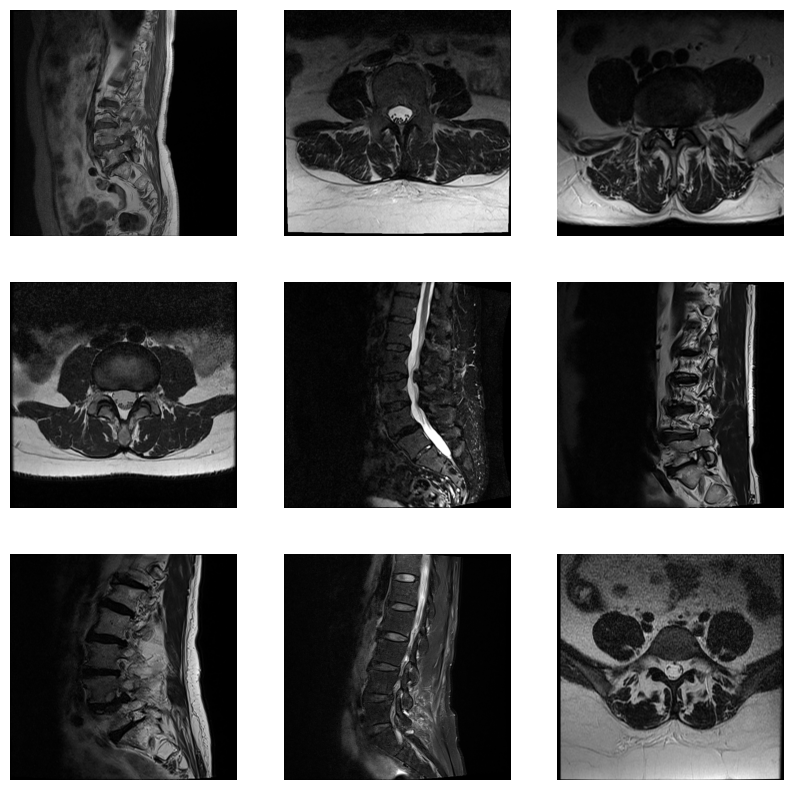

In [14]:
IMG_SIZE = (512, 512)


from utils import dicomToArray


# plt.figure(figsize=(10,10))
# _ = plt.imshow(dicomToArray(os.path.join(DATA_PATH, "train_images/3188843711/1039315139\\6.dcm"), IMG_SIZE), cmap="gray")
# _ = plt.colorbar()

plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(dicomToArray(filePath, IMG_SIZE), cmap="gray")
    _ = plt.axis("off")
# plt.colorbar()

## Dataset

In [15]:
import albumentations as A
import concurrent.futures
from more_itertools import chunked


transforms = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(max_pixel_value=1.0)
])

import random
random.seed(5584)
# random.shuffle(allFiles)


def transf(imArray):
    imArray = imArray/255.0
    imArray = transforms(image=imArray)["image"]
    return imArray

def loadIm(file):
    path = os.path.normpath(file)
    parts = path.split(os.sep)
    studyId, seriesId, instanceNr = int(parts[-3]), int(parts[-2]) ,int(parts[-1].split(".dcm")[0])
    label = getLabelVector(studyId, seriesId, instanceNr )
    im = dicomToArray(file, IMG_SIZE)
    im = im.astype(np.float32)
    im = transf(im)
    im = torch.Tensor(im)
    im = im[None,:,:]
    return im, label, studyId, seriesId, instanceNr


def generatorOld():
    for file in allFiles:
        im, label, studyId, seriesId, instanceNr = loadIm(file)
        yield im, np.array(label).astype(np.int64), {"studyId": studyId, "seriesId": seriesId, "instanceNr": instanceNr}

numWorkers=os.cpu_count()
print(f"Running data loading with {numWorkers} worker threads.")

def generator():
    with concurrent.futures.ThreadPoolExecutor(max_workers=numWorkers) as executor:
        for chunk in chunked(allFiles, numWorkers):
            futureIm = {executor.submit(loadIm, file): file for file in chunk}
            for future in concurrent.futures.as_completed(futureIm):
                url = futureIm[future]
                try:
                    im, label, studyId, seriesId, instanceNr = future.result()
                    yield im, np.array(label).astype(np.int64), {"studyId": studyId, "seriesId": seriesId, "instanceNr": instanceNr}
                except Exception as exc:
                    print('%r generated an exception: %s' % (url, exc))



g = generator()
testInstance = next(g)

tensor(-2.1179) tensor(2.2489)
torch.Size([1, 512, 512])
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[]


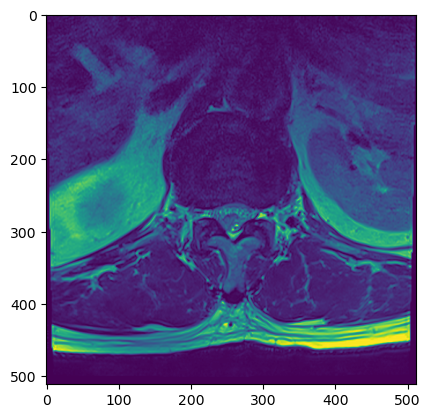

In [16]:
testInstance = next(g)

plt.imshow(testInstance[0][0,:,:])

print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])
print(allLabels[testInstance[1]>0])

In [17]:
BATCH_SIZE = 128

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    

dataset = IterDataset(generator, len(allFiles))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False )

In [18]:
for XData, targets, descr in trainLoader:
    print(f"Shape of X: {XData.shape} {XData.dtype}")
    print("Max and Min: ", torch.max(XData), torch.min(XData))
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    break

Shape of X: torch.Size([128, 1, 512, 512]) torch.float32
Max and Min:  tensor(2.2489) tensor(-2.1179)
Shape of target: torch.Size([128, 25]) torch.int64


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0])


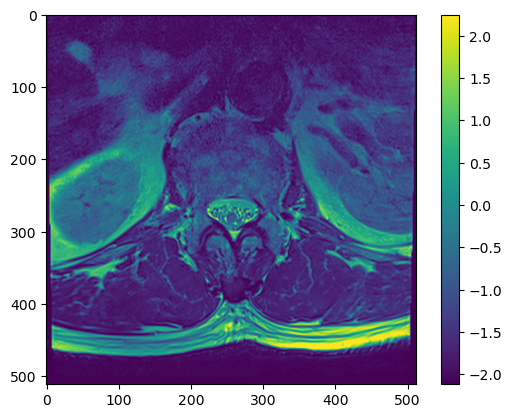

In [19]:
idx=4
print(targets[idx])
plt.imshow(XData[idx,0,:,:])
plt.colorbar()

## Model

In [20]:
import torchinfo


use_amp = True


class FeatExtractor(torch.nn.Module):
    def __init__(self, backbone):
        super(FeatExtractor, self).__init__()
        self.basemodel = timm.create_model(backbone, pretrained=True, num_classes=0, in_chans=1)
        self.name=f"FeatExtractor_{backbone}"

    def forward(self, x):
        x = self.basemodel(x)
        # x = torch.reshape(x, (x.shape[0], len(labelMapping), len(allLabels)))
        return x


model = FeatExtractor("resnet18d")

# from torchview import draw_graph

# model_graph = draw_graph(model, input_size=(BATCH_SIZE,1,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)
model = model.to(device)


with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
    print(torchinfo.summary(model, input_size=[BATCH_SIZE,1,IMG_SIZE[0],IMG_SIZE[1]], depth=3))

Layer (type:depth-idx)                        Output Shape              Param #
FeatExtractor                                 [128, 512]                --
├─ResNet: 1-1                                 [128, 512]                --
│    └─Sequential: 2-1                        [128, 64, 256, 256]       --
│    │    └─Conv2d: 3-1                       [128, 32, 256, 256]       288
│    │    └─BatchNorm2d: 3-2                  [128, 32, 256, 256]       64
│    │    └─ReLU: 3-3                         [128, 32, 256, 256]       --
│    │    └─Conv2d: 3-4                       [128, 32, 256, 256]       9,216
│    │    └─BatchNorm2d: 3-5                  [128, 32, 256, 256]       64
│    │    └─ReLU: 3-6                         [128, 32, 256, 256]       --
│    │    └─Conv2d: 3-7                       [128, 64, 256, 256]       18,432
│    └─BatchNorm2d: 2-2                       [128, 64, 256, 256]       128
│    └─ReLU: 2-3                              [128, 64, 256, 256]       --
│    └─MaxP

In [21]:

features=[]
labels=[]
descriptions=[]


model.eval()
with torch.no_grad():
    for X, y, descr in tqdm(trainLoader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        features.append(pred.detach().cpu().numpy())
        labels.append(y.detach().cpu().numpy())
        descriptions.append(descr)




print("Done!")

100%|██████████| 1151/1151 [41:05<00:00,  2.14s/it]

Done!


In [55]:
newFeatures=[]
newLabels=[]

studyIds=[]
seriesIds=[]
instanceNumbers=[]

for idx, descr in enumerate(descriptions):
    studyIds = [*studyIds, *descr["studyId"].numpy()]
    seriesIds = [*seriesIds, *descr["seriesId"].numpy()]
    instanceNumbers = [*instanceNumbers, *descr["instanceNr"].numpy()]
    # print(*features[idx])
    newFeatures = [*newFeatures, *features[idx]]
    newLabels = [*newLabels, *labels[idx]]


In [63]:
assert len(newLabels) == len(newFeatures)
assert len(newLabels) == len(instanceNumbers)
assert len(newLabels) == len(seriesIds)
assert len(newLabels) == len(studyIds)

In [60]:
import pickle

with open(os.path.join(DATA_PATH, "featureExtraction.pkl"), "wb") as f:
    pickle.dump({"features": newFeatures, "labels": newLabels, "studyIds": studyIds, "seriesIds": seriesIds, "instanceNumbers": instanceNumbers}, f)